<a href="https://colab.research.google.com/github/Thanaphon-673020253-2/project_bigdata/blob/main/PART3_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Part 3: Data Collection Robot + External Business Insight *(งานกลุ่ม — 25 คะแนน)*

ส่วนนี้ให้ทีมลอง **สร้าง dataset เล็ก ๆ ของตัวเอง** จากข้อมูลออนไลน์ แล้วใช้ตอบคำถามหนึ่งข้อ

เลือกวิธีเก็บเพียง **1 วิธี**
* API
* RSS
* Web Robot / Crawler / Scraper

## สิ่งที่ต้องทำ

1. ตั้งคำถามว่า **ข้อมูลนี้จะช่วยตัดสินใจเรื่องอะไร**
2. นิยามก่อนว่า **1 record คืออะไร** เช่น 1 ข่าว / 1 post / 1 complaint
3. เก็บอย่างน้อย **200 valid analytical records หลัง clean**
4. ตรวจ duplicate, missing และ record ที่ใช้ไม่ได้
5. ใช้เทคนิควิเคราะห์ที่เหมาะสม **1–2 เทคนิคก็เพียงพอ**
6. สรุป **1 Insight Card** พร้อมข้อจำกัด

**ข้อกำหนดด้านความรับผิดชอบ**
* เคารพ `robots.txt`, rate limit และ Terms of Service
* ใส่ delay เมื่อดึงหน้าเว็บ
* ห้าม bypass login, CAPTCHA หรือ paywall
* ไม่เก็บข้อมูลส่วนบุคคลที่ไม่จำเป็น

> Part 3 ไม่ได้วัดว่าใคร scrape ได้เยอะที่สุด แต่วัดว่าใครสร้างข้อมูลที่ใช้วิเคราะห์ได้จริงและตอบคำถามได้


### 3.1 เลือกแหล่งข้อมูลและวิธีเก็บ

เลือกแหล่งข้อมูลที่สัมพันธ์กับคำถามของทีม แล้วใช้ **เพียง 1 วิธีเก็บ**

ตัวอย่าง:
* Hacker News API — post + score + comments
* RSS — ข่าว/บทความ
* Traffy Fondue Open Data — เรื่องร้องเรียน
* เว็บไซต์สาธารณะที่อนุญาต crawler — ข่าว/บทความ/รายการต่าง ๆ

**กรอกก่อนเขียนโค้ด**
* แหล่งข้อมูล: ...
* คำถาม: ...
* ผู้ใช้ผลวิเคราะห์: ...
* **1 record คือ:** ...
* วิธีเก็บ: API / RSS / Robot
* field สำคัญที่จะเก็บ: ...

ด้านล่างมี
* **ตัวอย่างที่ 1:** API แบบสั้น
* **ตัวอย่างที่ 2–3:** ทางเลือกอื่นแบบสรุป
* **ตัวอย่างที่ 4:** Web Robot แบบอธิบายทีละขั้น


* # Source : The Movie DB
* # Question :
* # Person Analytic : platform streaming
* # 1 record  : 1 review


# **3.1 เตรียมข้อมูล**
* # ไม่ต้องรันแล้ว ใช้ไฟล์ที่โหลดเอานะ

In [ ]:
# ===== Setup =====
import os, json, time
from getpass import getpass
import numpy as np
import pandas as pd
import requests

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- โฟลเดอร์และไฟล์ ----
DATA_DIR      = "./data_part3/"
os.makedirs(DATA_DIR, exist_ok=True)
TV_RAW_PATH   = DATA_DIR + "tmdb_tv_raw.jsonl"
REV_RAW_PATH  = DATA_DIR + "tmdb_reviews_raw.jsonl"
LOG_PATH      = DATA_DIR + "collection_log.json"
CORPUS_JSONL  = DATA_DIR + "tmdb_corpus_clean.jsonl"
CORPUS_CSV    = DATA_DIR + "tmdb_corpus_clean.csv"

# ---- สวิตช์: False = ถ้ามีไฟล์ raw อยู่แล้วให้ใช้ไฟล์เดิม (ข้อมูลไม่เปลี่ยน) ----
FORCE_REFETCH = False

# ---- พารามิเตอร์การเก็บข้อมูล ----
LANGUAGE         = "en-US"
SORT_BY          = "popularity.desc"
MAX_PAGES        = 30        # 1 หน้า = 20 เรื่อง -> ~600 เรื่อง
MAX_REVIEW_PAGES = 30        # 1 หน้า <= 20 รีวิว/เรื่อง (หยุดเองเมื่อหมดหน้า)
DELAY            = 0.1       # วินาที ระหว่าง request

print("ข้อมูลจะถูกบันทึกที่:", os.path.abspath(DATA_DIR))

ข้อมูลจะถูกบันทึกที่: /content/data_part3


# ฟังก์ชันที่ใช้เก็บข้อมูล
ยังไม่เรียก API ในเซลล์นี้ (token จะถูกขอเมื่อมีการเรียกครั้งแรกเท่านั้น)

# --------------------------**ห้ามรันตั้งแต่ส่วนนี้น้า** ---------------------------

In [ ]:
# ===== A0: ฟังก์ชัน =====
BASE_URL = "https://api.themoviedb.org/3"
session = None

def get_session():
    """ใช้ "API Read Access Token" (ขึ้นต้น eyJ...) ไม่ใช่ API Key 32 ตัว
    Colab: เก็บเป็น Secret ชื่อ TMDB_TOKEN | ที่อื่น: ตัวแปรสภาพแวดล้อม TMDB_TOKEN หรือพิมพ์ตอนรัน
    ห้ามเขียน token ลงใน notebook"""
    try:
        from google.colab import userdata
        token = userdata.get("TMDB_TOKEN")
    except Exception:
        token = os.environ.get("TMDB_TOKEN") or getpass("วาง TMDB API Read Access Token: ")
    s = requests.Session()
    s.headers.update({"Authorization": f"Bearer {token}", "accept": "application/json"})
    return s

def tmdb_get(path, params=None, retries=4):
    """เรียก TMDB พร้อม retry เมื่อโดน rate limit (429) หรือ server error (5xx)"""
    global session
    if session is None:
        session = get_session()
    for attempt in range(retries):
        r = session.get(BASE_URL + path, params=params, timeout=20)
        if r.status_code == 429:
            wait = int(r.headers.get("Retry-After", 2))
            print(f"โดน rate limit รอ {wait}s ...")
            time.sleep(wait)
            continue
        if r.status_code >= 500:
            time.sleep(2 * (attempt + 1))
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError(f"เรียก {path} ไม่สำเร็จหลัง {retries} ครั้ง")

def load_jsonl(path):
    """อ่าน JSON Lines ทีละบรรทัด (ถ้าไฟล์เสียจะบอกเลขบรรทัด)"""
    rows = []
    with open(path, encoding="utf-8") as f:
        for n, line in enumerate(f, 1):
            if line.strip():
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as e:
                    raise ValueError(f"{path} บรรทัด {n} อ่านไม่ได้: {e}")
    return pd.DataFrame(rows)

def save_jsonl(df, path):
    df.to_json(path, orient="records", lines=True, force_ascii=False, date_format="iso")

def load_log():
    return json.load(open(LOG_PATH, encoding="utf-8")) if os.path.exists(LOG_PATH) else {}

def save_log(log):
    json.dump(log, open(LOG_PATH, "w", encoding="utf-8"), ensure_ascii=False, indent=1)

# เก็บซีรีส์ (/discover/tv → /tv/{id})
ถ้ามี tmdb_tv_raw.jsonl อยู่แล้วและ FORCE_REFETCH = False จะอ่านไฟล์เดิม ไม่เรียก API

In [ ]:
# ===== A1: ซีรีส์ =====
def fetch_discover(max_pages=MAX_PAGES):
    rows = []
    for page in range(1, max_pages + 1):
        data = tmdb_get("/discover/tv", {"language": LANGUAGE, "sort_by": SORT_BY,
                                         "include_adult": "false", "page": page})
        results = data.get("results", [])
        if not results:
            break
        rows.extend(results)
        if page % 10 == 0:
            print(f"ดึงรายการแล้ว {page} หน้า / {len(rows)} เรื่อง")
        if page >= data.get("total_pages", page):
            break
        time.sleep(DELAY)
    return rows

def build_tv_record(d, item, genre_map):
    tv_id = d["id"]
    return {
        "doc_id": str(tv_id),
        "name": d.get("name"),
        "original_name": d.get("original_name"),
        "original_language": d.get("original_language"),
        "origin_country": "|".join(d.get("origin_country") or []),
        "first_air_date": d.get("first_air_date"),
        "last_air_date": d.get("last_air_date"),
        "genres": "|".join(g["name"] for g in d.get("genres", [])) or "|".join(genre_map.get(x, str(x)) for x in item.get("genre_ids", [])),
        "overview": d.get("overview") or item.get("overview") or "",
        "vote_average": d.get("vote_average"),
        "vote_count": d.get("vote_count"),
        "popularity": d.get("popularity"),
        "number_of_seasons": d.get("number_of_seasons"),
        "number_of_episodes": d.get("number_of_episodes"),
        "status": d.get("status"),
        "in_production": d.get("in_production"),
        "source": "tmdb",
        "url": f"https://www.themoviedb.org/tv/{tv_id}",
    }

if os.path.exists(TV_RAW_PATH) and not FORCE_REFETCH:
    print("พบ", TV_RAW_PATH, "-> ใช้ไฟล์เดิม ไม่เรียก API")
    df_tv_raw = load_jsonl(TV_RAW_PATH)
    df_tv_raw["doc_id"] = df_tv_raw["doc_id"].astype(str)
    log = load_log()
else:
    genre_map = {g["id"]: g["name"] for g in tmdb_get("/genre/tv/list", {"language": LANGUAGE})["genres"]}
    list_rows = fetch_discover()

    seen, uniq = set(), []                         # /discover/tv อาจส่งซีรีส์เดิมซ้ำข้ามหน้า -> ตัดก่อนเรียก detail
    for it in list_rows:
        if it["id"] not in seen:
            seen.add(it["id"]); uniq.append(it)

    records, failed = [], []
    for i, item in enumerate(uniq, start=1):
        try:
            records.append(build_tv_record(tmdb_get(f"/tv/{item['id']}", {"language": LANGUAGE}), item, genre_map))
        except Exception as e:
            failed.append((item["id"], str(e)))
        if i % 100 == 0:
            print(f"detail {i}/{len(uniq)}")
        time.sleep(DELAY)

    df_tv_raw = pd.DataFrame(records)
    save_jsonl(df_tv_raw, TV_RAW_PATH)
    log = {"series_listed": len(list_rows), "series_list_duplicates": len(list_rows) - len(uniq),
           "series_detail_ok": len(records), "series_detail_failed": len(failed)}
    save_log(log)
    print(f"✅ ซีรีส์: รายการ {len(list_rows)} -> ไม่ซ้ำ {len(uniq)} -> detail สำเร็จ {len(records)} / ล้มเหลว {len(failed)}")

print("ซีรีส์ดิบ:", len(df_tv_raw), "เรื่อง")

ดึงรายการแล้ว 10 หน้า / 200 เรื่อง
ดึงรายการแล้ว 20 หน้า / 400 เรื่อง
ดึงรายการแล้ว 30 หน้า / 600 เรื่อง
detail 100/596
detail 200/596
detail 300/596
detail 400/596
detail 500/596
✅ ซีรีส์: รายการ 600 -> ไม่ซ้ำ 596 -> detail สำเร็จ 596 / ล้มเหลว 0
ซีรีส์ดิบ: 596 เรื่อง


# เก็บรีวิว (/tv/{id}/reviews)
วนทีละซีรีส์ ไม่ซ้ำ id (ไม่วนตามตารางที่มี id ซ้ำ) และไม่เก็บชื่อผู้รีวิว

In [ ]:
MAX_REVIEW_PAGES_LOCAL = MAX_REVIEW_PAGES

def fetch_reviews(tv_id, max_pages=MAX_REVIEW_PAGES_LOCAL):
    out = []
    for page in range(1, max_pages + 1):
        data = tmdb_get(f"/tv/{tv_id}/reviews", {"page": page})
        for r in data.get("results", []):
            out.append({
                "review_id": r.get("id"),
                "doc_id": str(tv_id),
                "text": r.get("content") or "",
                "user_rating": (r.get("author_details") or {}).get("rating"),   # อาจเป็น None
                "created_at": r.get("created_at"),
                # ไม่เก็บ author/username เพื่อลดข้อมูลส่วนบุคคล (PDPA)
            })
        if page >= data.get("total_pages", 1):
            break
        time.sleep(DELAY)
    return out

if os.path.exists(REV_RAW_PATH) and not FORCE_REFETCH:
    print("พบ", REV_RAW_PATH, "-> ใช้ไฟล์เดิม ไม่เรียก API")
    df_rev_raw = load_jsonl(REV_RAW_PATH)
    df_rev_raw["doc_id"] = df_rev_raw["doc_id"].astype(str)
else:
    ids = df_tv_raw["doc_id"].drop_duplicates().tolist()
    rev_rows, rev_failed = [], []
    for i, tv_id in enumerate(ids, start=1):
        try:
            rev_rows.extend(fetch_reviews(tv_id))
        except Exception as e:
            rev_failed.append(tv_id)
        if i % 100 == 0:
            print(f"{i}/{len(ids)} เรื่อง | รีวิวสะสม {len(rev_rows)}")
        time.sleep(DELAY)

    n_first_fail = len(rev_failed)                  # ลองใหม่อีก 1 รอบสำหรับเรื่องที่ล้มเหลว
    still_failed = []
    for tv_id in rev_failed:
        try:
            rev_rows.extend(fetch_reviews(tv_id))
        except Exception:
            still_failed.append(tv_id)
        time.sleep(DELAY)

    df_rev_raw = pd.DataFrame(rev_rows)
    save_jsonl(df_rev_raw, REV_RAW_PATH)
    log.update({"review_series_requested": len(ids), "review_series_failed_first_try": n_first_fail,
                "review_series_failed_final": len(still_failed), "review_rows_raw": len(df_rev_raw)})
    save_log(log)
    print(f"✅ รีวิว: ขอจาก {len(ids)} เรื่อง -> ได้ {len(df_rev_raw)} แถว | ล้มเหลวรอบแรก {n_first_fail} / หลังลองใหม่ {len(still_failed)}")

print("รีวิวดิบ:", len(df_rev_raw), "แถว")

100/596 เรื่อง | รีวิวสะสม 144
200/596 เรื่อง | รีวิวสะสม 273
300/596 เรื่อง | รีวิวสะสม 335
400/596 เรื่อง | รีวิวสะสม 408
500/596 เรื่อง | รีวิวสะสม 490
✅ รีวิว: ขอจาก 596 เรื่อง -> ได้ 576 แถว | ล้มเหลวรอบแรก 0 / หลังลองใหม่ 0
รีวิวดิบ: 576 แถว


# --------------------------**ห้ามรันจนถึงส่วนนี้น้า** ---------------------------

# **3.2 ตรวจคุณภาพข้อมูล (Clean + Quality Report)**
ลำดับ: Clean ซีรีส์ → Clean รีวิว → Join → รายงาน → บันทึก final corpus
ทุกเซลล์ในส่วนนี้ใช้เฉพาะไฟล์ raw ที่โหลดแล้ว จึงรันซ้ำได้โดยผลเดิม

In [ ]:
# ===== 3.2 ตรวจคุณภาพข้อมูล =====
# ===== อ่านข้อมูล Raw จากไฟล์ =====

import pandas as pd

df_raw = pd.read_json(
    "tmdb_tv_raw.jsonl",
    lines=True
)                                                           # อ่านข้อมูล TV Series ดิบ

df_rev_raw = pd.read_json(
    "tmdb_reviews_raw.jsonl",
    lines=True
)                                                           # อ่านข้อมูล Reviews ดิบ

print("TV Series Raw :", len(df_raw), "records")
print("Reviews Raw   :", len(df_rev_raw), "records")

TV Series Raw : 596 records
Reviews Raw   : 576 records


In [ ]:
# ===== Clean ข้อมูล TV Series =====

tv_clean = df_raw.copy()                                    # สำเนาข้อมูล TV Series ดิบ
tv_before = len(tv_clean)                                   # จำนวนข้อมูลก่อน Clean

tv_duplicate = tv_clean.duplicated(
    subset=["doc_id"], keep="first"
)                                                           # ตรวจ doc_id ที่ซ้ำ
n_tv_duplicate = tv_duplicate.sum()
tv_clean = tv_clean[~tv_duplicate].copy()                   # ตัดข้อมูลซ้ำออก

tv_missing_id = (
    tv_clean["doc_id"].isna() |
    tv_clean["doc_id"].astype(str).str.strip().eq("")
)                                                           # ตรวจ doc_id ที่หายไป

n_tv_missing_id = tv_missing_id.sum()
tv_clean = tv_clean[~tv_missing_id].copy()                  # ตัด record ที่ไม่มี doc_id

tv_clean["first_air_date"] = pd.to_datetime(
    tv_clean["first_air_date"], errors="coerce"
)                                                           # แปลงวันที่เป็น datetime

tv_clean["last_air_date"] = pd.to_datetime(
    tv_clean["last_air_date"], errors="coerce"
)                                                           # แปลงวันที่เป็น datetime

tv_clean = tv_clean.reset_index(drop=True)                  # จัด index ใหม่

print("===== TV SERIES CLEANING =====")
print("ก่อน Clean        :", tv_before)
print("Duplicate         :", n_tv_duplicate)
print("Missing doc_id    :", n_tv_missing_id)
print("หลัง Clean         :", len(tv_clean))

===== TV SERIES CLEANING =====
ก่อน Clean        : 596
Duplicate         : 0
Missing doc_id    : 0
หลัง Clean         : 596


In [ ]:
# ===== Clean ข้อมูล Reviews =====

rev_clean = df_rev_raw.copy()                                # สำเนาข้อมูล Reviews ดิบ
rev_before = len(rev_clean)                                  # จำนวน Reviews ก่อน Clean

rev_duplicate = rev_clean.duplicated(
    subset=["review_id"], keep="first"
)                                                           # ตรวจ review_id ที่ซ้ำ

n_rev_duplicate = rev_duplicate.sum()
rev_clean = rev_clean[~rev_duplicate].copy()                 # ตัด Reviews ที่ซ้ำ

rev_clean["text"] = rev_clean["text"].fillna("").str.strip() # จัดการ text ที่เป็น missing
missing_text = rev_clean["text"].eq("")                      # ตรวจข้อความที่ว่าง
n_rev_missing = missing_text.sum()
rev_clean = rev_clean[~missing_text].copy()                  # ตัด Reviews ที่ไม่มีข้อความ

rev_clean["text_length"] = rev_clean["text"].str.len()       # นับจำนวนตัวอักษรของแต่ละ Review

print("===== REVIEW QUALITY CHECK =====")
print("ก่อน Clean          :", rev_before)
print("Duplicate           :", n_rev_duplicate)
print("Missing text        :", n_rev_missing)

print("\nความยาว Review:")
print(rev_clean["text_length"].describe())

===== REVIEW QUALITY CHECK =====
ก่อน Clean          : 576
Duplicate           : 0
Missing text        : 0

ความยาว Review:
count      576.000000
mean      1153.302083
std       2486.228158
min          4.000000
25%        273.000000
50%        578.000000
75%       1097.500000
max      33616.000000
Name: text_length, dtype: float64


In [ ]:
# ===== ตัด Reviews ที่สั้นผิดปกติ =====

MIN_REVIEW_LENGTH = 50                                      # กำหนดข้อความสั้นผิดปกติน้อยกว่า 50 ตัวอักษร

short_mask = rev_clean["text_length"] < MIN_REVIEW_LENGTH   # ตรวจ Review ที่สั้นผิดปกติ
n_rev_short = short_mask.sum()

rev_clean = rev_clean[~short_mask].copy()                   # ตัด Review ที่สั้นผิดปกติ
rev_clean = rev_clean.reset_index(drop=True)                # จัด index ใหม่

print("Review สั้นกว่า", MIN_REVIEW_LENGTH, "ตัวอักษร =", n_rev_short)
print("Reviews หลัง Clean =", len(rev_clean))

Review สั้นกว่า 50 ตัวอักษร = 24
Reviews หลัง Clean = 552


In [ ]:
# ===== Join TV Series กับ Reviews =====

corp = rev_clean.merge(
    tv_clean,
    on="doc_id",
    how="inner"
)                                                           # เชื่อม Reviews กับ TV Series ด้วย doc_id

print("Reviews ก่อน Join =", len(rev_clean))
print("Final corpus หลัง Join =", len(corp))
print("จำนวนซีรีส์ใน corpus =", corp["doc_id"].nunique())

Reviews ก่อน Join = 552
Final corpus หลัง Join = 552
จำนวนซีรีส์ใน corpus = 204


In [ ]:
# ===== Final Data Quality Report =====

n_join_removed = len(rev_clean) - len(corp)                 # จำนวน Review ที่ Join ไม่ได้

print("===== DATA QUALITY REPORT =====")
print(f"Reviews ที่เก็บได้ทั้งหมด       : {rev_before} records")
print(f"Duplicate                       : {n_rev_duplicate}")
print(f"Missing text                    : {n_rev_missing}")
print(f"ข้อความสั้นกว่า {MIN_REVIEW_LENGTH} ตัวอักษร   : {n_rev_short}")
print(f"Join กับ TV Series ไม่ได้       : {n_join_removed}")

print("\n===== FINAL CORPUS =====")
print(f"Final corpus                    : {len(corp)} records")
print(f"จำนวนซีรีส์                     : {corp['doc_id'].nunique()} เรื่อง")

print("\nช่วงเวลาของ Reviews:")
print(
    pd.to_datetime(corp["created_at"], errors="coerce").min(),
    "ถึง",
    pd.to_datetime(corp["created_at"], errors="coerce").max()
)

genres_covered = sorted({
    genre
    for genres in corp["genres"].dropna()
    for genre in genres.split("|")
    if genre
})                                                          # ตรวจ Genres ที่ corpus ครอบคลุม

print("\nGenres ที่ครอบคลุม:")
print(genres_covered)
print("จำนวน Genres =", len(genres_covered))

if len(corp) >= 200:
    print("\nผ่านเกณฑ์: มีอย่างน้อย 200 valid analytical records")
else:
    print("\nยังไม่ผ่านเกณฑ์: มีน้อยกว่า 200 valid analytical records")

===== DATA QUALITY REPORT =====
Reviews ที่เก็บได้ทั้งหมด       : 576 records
Duplicate                       : 0
Missing text                    : 0
ข้อความสั้นกว่า 50 ตัวอักษร   : 24
Join กับ TV Series ไม่ได้       : 0

===== FINAL CORPUS =====
Final corpus                    : 552 records
จำนวนซีรีส์                     : 204 เรื่อง

ช่วงเวลาของ Reviews:
2017-02-11 21:46:06+00:00 ถึง 2026-09-29 21:26:10+00:00

Genres ที่ครอบคลุม:
['Action & Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Kids', 'Mystery', 'News', 'Reality', 'Sci-Fi & Fantasy', 'Soap', 'Talk', 'War & Politics', 'Western']
จำนวน Genres = 15

ผ่านเกณฑ์: มีอย่างน้อย 200 valid analytical records


In [ ]:
# ===== บันทึก Final corpus =====

jsonl_path = "tmdb_corpus_clean.jsonl"                      # Final corpus แบบ JSONL
csv_path = "tmdb_corpus_clean.csv"                          # Final corpus แบบ CSV

corp.to_json(
    jsonl_path,
    orient="records",
    lines=True,
    force_ascii=False,
    date_format="iso"
)

corp.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", jsonl_path)
print("Saved:", csv_path)

corp_check = pd.read_json(jsonl_path, lines=True)            # ตรวจว่าไฟล์อ่านกลับได้
print("อ่านกลับได้ =", len(corp_check), "records")

Saved: tmdb_corpus_clean.jsonl
Saved: tmdb_corpus_clean.csv
อ่านกลับได้ = 552 records


# ---------------**ส่วนข้างบนนี้ก็ไม่ต้องรันแล้วไปโหลดในไดร์ฟแล้วอ่านไฟล์เอานะ**--------------

### 3.3 หา Insight

ใช้ **1–2 เทคนิค** ที่เหมาะกับคำถาม เช่น

* frequency / n-gram
* sentiment
* topic
* comparison ระหว่างกลุ่ม
* trend ตามเวลา

สร้างกราฟหรือตารางหลักอย่างน้อย **1 ชิ้น** แล้วตอบว่า

> “จากข้อมูลนี้ ผู้ใช้ผลวิเคราะห์ควรรู้อะไรหรือทำอะไรต่อ?”


In [101]:
CUSTOM_STOP = {"show", "shows", "series", "season", "seasons", "episode", "episodes", "watch", "watched",
               "watching", "tv", "really", "just", "like", "would", "could", "also", "get", "got", "make",
               "made", "thing", "things", "even", "still", "much", "many", "lot", "one", "bit"}
STOP = set(ENGLISH_STOP_WORDS) | CUSTOM_STOP

SKIP = r"(?:a|an|the|very|so|too|really|that|even|as|be|been|being|is|are|was|were|do|does|did|have|has|had|to|just|much|all|quite)"
NEG_RE = re.compile(rf"\b(?:not|no|never|hardly|barely)\s+(?:{SKIP}\s+)*([a-z]+)")

def clean_review(text, title=""):
    t = str(text).lower().replace("’", "'").replace("‘", "'")
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)                  # URL
    t = re.sub(r"[*#_>`]+", " ", t)                               # markdown
    if title:                                                     # ลบชื่อซีรีส์ของรีวิวนี้เท่านั้น
        t = re.sub(r"(?<!\w)" + re.escape(str(title).lower()) + r"(?!\w)", " ", t)
    t = (t.replace("can't", "can not").replace("cannot", "can not")
           .replace("won't", "will not").replace("n't", " not"))   # ขยายคำย่อปฏิเสธ
    t = re.sub(r"'(?:s|re|ve|ll|d|m)\b", " ", t)                  # 's 're 've 'll 'd 'm
    t = NEG_RE.sub(lambda m: " " if m.group(1) in STOP else f" neg_{m.group(1)} ", t)
    t = re.sub(r"[^a-z_\s]", " ", t)                              # เหลือตัวอักษรกับ _
    return " ".join(w for w in t.split() if len(w) >= 3 and w not in STOP)

df["clean"] = [clean_review(t, n) for t, n in zip(df["text"], df["name"])]
n_before = len(df)
df = df[df["clean"].str.strip() != ""].copy()
print(f"ตัดรีวิวที่ว่างหลังล้างข้อความ {n_before - len(df)} -> เหลือ {len(df)}")

# ตรวจด้วยตา: ตัวอย่างที่มีคำปฏิเสธ
ex = df[df["clean"].str.contains("neg_")].sample(3, random_state=RANDOM_SEED)
for _, r in ex.iterrows():
    print(f"\n[{r['name']}] คะแนน {r['user_rating']:.0f}")
    print("  ต้นฉบับ:", re.sub(r"\s+", " ", r["text"])[:160])
    print("  หลังล้าง:", r["clean"][:160])

ตัดรีวิวที่ว่างหลังล้างข้อความ 0 -> เหลือ 448

[The Simpsons] คะแนน 8
  ต้นฉบับ: It's not as good as it used to be, but the old episodes are glorious. I personally consider the classics as Seasons 1-19 (though you may consider them a differe
  หลังล้าง: neg_good used old glorious personally consider classics consider different timeframe better humor voice actors sound great marge cries sounds present marge clas

[Star Trek: Strange New Worlds] คะแนน 1
  ต้นฉบับ: After watching season 4 I finally get the intent of the writers. It seems they are mocking Star Trek fans by writing the most awful twaddle they can. If you loo
  หลังล้าง: finally intent writers mocking star trek fans writing awful twaddle looked stupid sci script years star trek stupid new worlds appears writers hate trying kill 

[Murder, She Wrote] คะแนน 9
  ต้นฉบับ: I'm starting to see why my mum liked this show... It's on every Saturday all day on 5 USA, first of, and secondly, it is rather entertaining. This delightful l

In [102]:
def contrast(d, low_max=LOW_MAX, high_min=HIGH_MIN, min_docs=MIN_DOCS):
    d = d[(d["user_rating"] <= low_max) | (d["user_rating"] >= high_min)].reset_index(drop=True)
    y = (d["user_rating"] <= low_max).values                       # True = กลุ่มต่ำ

    cv = CountVectorizer(binary=True, lowercase=False, min_df=min_docs, token_pattern=r"[a-z_]{3,}")
    X = cv.fit_transform(d["clean"]).tocsr()
    terms = cv.get_feature_names_out()

    codes = pd.factorize(d["doc_id"])[0]                           # รหัสซีรีส์ของแต่ละรีวิว
    S = csr_matrix((np.ones(len(d)), (codes, np.arange(len(d)))), shape=(codes.max() + 1, len(d)))

    def group_stats(mask):
        idx = np.where(mask)[0]
        Xg, Sg = X[idx], S[:, idx]
        docs = np.asarray(Xg.sum(axis=0)).ravel()                  # จำนวนรีวิวที่มีคำนี้
        per_series = (Sg @ Xg).toarray()                           # ซีรีส์ x คำ
        n_series = (per_series > 0).sum(axis=0)                    # จำนวนซีรีส์ที่ต่างกัน
        top_share = per_series.max(axis=0) / np.maximum(docs, 1)   # สัดส่วนที่มาจากซีรีส์เดียว
        return docs, n_series, top_share

    a, sa, ta = group_stats(y)
    b, sb, tb = group_stats(~y)
    nl, nh = int(y.sum()), int((~y).sum())
    lor = np.log((a + .5) / (nl - a + .5)) - np.log((b + .5) / (nh - b + .5))
    se = np.sqrt(1 / (a + .5) + 1 / (nl - a + .5) + 1 / (b + .5) + 1 / (nh - b + .5))

    out = pd.DataFrame({
        "term": [("not " + t[4:]) if t.startswith("neg_") else t for t in terms],
        "low_reviews": a, "high_reviews": b,
        "low_pct": a / nl * 100, "high_pct": b / nh * 100,
        "low_series": sa, "high_series": sb,
        "low_top_series_%": ta * 100, "high_top_series_%": tb * 100,
        "z": lor / se,
    })
    return out, nl, nh

def pick_terms(res, side, k=15, min_docs=MIN_DOCS, min_series=MIN_SERIES):
    if side == "low":
        r = res[(res["low_reviews"] >= min_docs) & (res["low_series"] >= min_series) & (res["z"] > 0)]
        return r.sort_values("z", ascending=False).head(k)
    r = res[(res["high_reviews"] >= min_docs) & (res["high_series"] >= min_series) & (res["z"] < 0)]
    return r.sort_values("z").head(k)

res, n_low, n_high = contrast(df)
low_terms, high_terms = pick_terms(res, "low"), pick_terms(res, "high")

print(f"กลุ่มต่ำ n = {n_low} รีวิว | กลุ่มสูง n = {n_high} รีวิว | คำที่นำมาเทียบ {len(res)} คำ")
cols = ["term", "low_reviews", "high_reviews", "low_pct", "high_pct", "low_series", "z"]
print("\nคำที่พบมากกว่าในรีวิวคะแนนต่ำ:");  display(low_terms[cols].round(2).reset_index(drop=True))
cols_h = ["term", "high_reviews", "low_reviews", "high_pct", "low_pct", "high_series", "z"]
print("คำที่พบมากกว่าในรีวิวคะแนนสูง:");   display(high_terms[cols_h].round(2).reset_index(drop=True))

กลุ่มต่ำ n = 103 รีวิว | กลุ่มสูง n = 196 รีวิว | คำที่นำมาเทียบ 938 คำ

คำที่พบมากกว่าในรีวิวคะแนนต่ำ:


,term,low_reviews,high_reviews,low_pct,high_pct,low_series,z
0,woke,17,4,16.50,2.04,14,3.97
1,boring,15,7,14.56,3.57,14,3.21
2,stupid,11,2,10.68,1.02,10,3.20
3,said,14,6,13.59,3.06,14,3.18
4,supposed,11,1,10.68,0.51,7,3.17
5,propaganda,10,3,9.71,1.53,10,2.90
6,white,10,3,9.71,1.53,8,2.90
7,star,15,9,14.56,4.59,8,2.87
8,justice,8,2,7.77,1.02,8,2.65
9,not bad,8,2,7.77,1.02,8,2.65


คำที่พบมากกว่าในรีวิวคะแนนสูง:


,term,high_reviews,low_reviews,high_pct,low_pct,high_series,z
0,love,38,4,19.39,3.88,33,-3.27
1,best,50,9,25.51,8.74,41,-3.26
2,great,52,10,26.53,9.71,43,-3.23
3,television,27,1,13.78,0.97,25,-2.84
4,character,50,12,25.51,11.65,43,-2.70
5,heart,21,2,10.71,1.94,19,-2.36
6,definitely,17,1,8.67,0.97,16,-2.21
7,cast,32,7,16.33,6.80,27,-2.20
8,fun,24,4,12.24,3.88,23,-2.17
9,recommend,16,1,8.16,0.97,16,-2.13


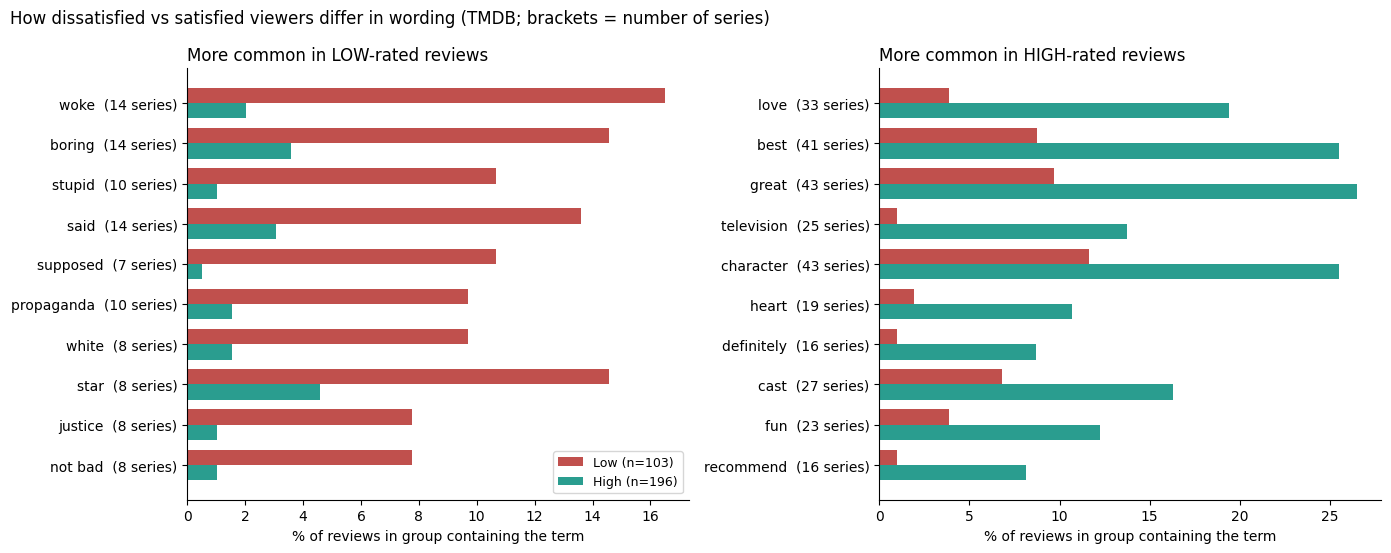

In [107]:
from matplotlib import font_manager as fm
THAI_FONTS = ["Tahoma", "Leelawadee UI", "Noto Sans Thai", "Sarabun", "TH Sarabun New", "Garuda", "Loma", "Tlwg Typo"]
_avail = {f.name for f in fm.fontManager.ttflist}
_thai = next((f for f in THAI_FONTS if f in _avail), None)
if _thai:
    plt.rcParams["font.family"] = _thai
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False})
T = (lambda th, en: th) if _thai else (lambda th, en: en)      # เลือกป้ายตามฟอนต์ที่มี

C_LOW, C_HIGH, C_MID = "#C0504D", "#2A9D8F", "#B0B0B0"

# ---------- ปรียบเทียบคำ ----------
def draw_panel(ax, table, title, order_col):
    t = table.head(10).iloc[::-1]                       # คำที่เด่นสุดอยู่บน
    y = np.arange(len(t)); h = 0.38
    ax.barh(y + h / 2, t["low_pct"], height=h, color=C_LOW, label=T(f"กลุ่มต่ำ (n={n_low})", f"Low (n={n_low})"))
    ax.barh(y - h / 2, t["high_pct"], height=h, color=C_HIGH, label=T(f"กลุ่มสูง (n={n_high})", f"High (n={n_high})"))
    ax.set_yticks(y)
    ax.set_yticklabels([f"{w}  ({int(s)} {T('ซีรีส์', 'series')})" for w, s in zip(t["term"], t[order_col])], fontsize=10)
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_xlabel(T("% ของรีวิวในกลุ่มที่มีคำนี้", "% of reviews in group containing the term"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
draw_panel(axes[0], low_terms, T("คำที่พบมากกว่าในรีวิวคะแนนต่ำ", "More common in LOW-rated reviews"), "low_series")
draw_panel(axes[1], high_terms, T("คำที่พบมากกว่าในรีวิวคะแนนสูง", "More common in HIGH-rated reviews"), "high_series")
axes[0].legend(loc="lower right", fontsize=9)
fig.suptitle(T("ผู้ชมที่ไม่พอใจกับผู้ชมที่พอใจใช้คำต่างกันอย่างไร (TMDB, ตัวเลขในวงเล็บ = จำนวนซีรีส์ที่พบคำนั้น)",
               "How dissatisfied vs satisfied viewers differ in wording (TMDB; brackets = number of series)"), fontsize=12, x=0.01, ha="left")
plt.tight_layout(); plt.show()

In [106]:
# ---------- ทดสอบ 1: ความกระจุกตัว ----------
chk = low_terms[["term", "low_reviews", "low_series", "low_top_series_%"]].copy()
chk["กระจุกตัว"] = np.where(chk["low_top_series_%"] >= 50, "ระวัง (>=50% จากซีรีส์เดียว)", "ok")
print("ความกระจุกตัวของคำเด่นในรีวิวคะแนนต่ำ:"); display(chk.round(1).reset_index(drop=True))

# ---------- ทดสอบ 2: อ่านบริบทจริง (KWIC) ----------
def show_examples(term, group="low", k=3, width=70):
    base = term[4:] if term.startswith("not ") else term
    sel = df[(df["group"] == group) & df["clean"].str.contains(rf"\b(?:neg_)?{re.escape(base)}\b")]
    print(f"\n=== '{term}' ({group}) พบ {len(sel)} รีวิว ===")
    for _, r in sel.sample(min(k, len(sel)), random_state=RANDOM_SEED).iterrows():
        raw = re.sub(r"\s+", " ", r["text"].replace("’", "'"))
        m = re.search(re.escape(base), raw, flags=re.I)
        s = max(m.start() - width, 0) if m else 0
        print(f"  [{r['name'][:24]} | {r['user_rating']:.0f}/10] ...{raw[s:s + 2 * width]}...")

for w in low_terms["term"].head(3):          # ดู 3 คำแรกก่อน เปลี่ยนเป็นคำอื่นได้
    show_examples(w, "low")

# ---------- ทดสอบ 3: ความทนทานต่อการเปลี่ยนเกณฑ์ ----------
main_top = set(low_terms["term"].head(15))
pop_cut = df.drop_duplicates("doc_id")["popularity"].median()
variants = {
    "ต่ำ<=3 / สูง>=9": (df, 3, 9),
    "ต่ำ<=4 / สูง>=8": (df, 4, 8),
    "ต่ำ<=5 / สูง>=9": (df, 5, 9),
    "เฉพาะซีรีส์ popularity สูงกว่ามัธยฐาน": (df[df["popularity"] >= pop_cut], 4, 9),
}
rows = []
for name, (d_, lo_, hi_) in variants.items():
    r_, nl_, nh_ = contrast(d_, lo_, hi_)
    top_ = set(pick_terms(r_, "low", 15)["term"])
    rows.append({"ตัวแปร": name, "n ต่ำ": nl_, "n สูง": nh_, "คำเด่น (ซ้อนกับผลหลัก จาก 15)": len(main_top & top_)})
print("\nความทนทาน:"); display(pd.DataFrame(rows))

ความกระจุกตัวของคำเด่นในรีวิวคะแนนต่ำ:


,term,low_reviews,low_series,low_top_series_%,กระจุกตัว
0,woke,17,14,17.6,ok
1,boring,15,14,13.3,ok
2,stupid,11,10,18.2,ok
3,said,14,14,7.1,ok
4,supposed,11,7,45.5,ok
5,propaganda,10,10,10.0,ok
6,white,10,8,20.0,ok
7,star,15,8,26.7,ok
8,justice,8,8,12.5,ok
9,not bad,8,8,12.5,ok



=== 'woke' (low) พบ 17 รีวิว ===
  [Reacher | 4/10] ...SEASON 1: 8/10! Dean even said it had zero wokery, which is weird since they highlighted Finlay's race multiple times, but I guess it's only...
  [Silo | 4/10] ... itself isn't bad. It's interesting, but sadly it's infected with DEI woke propaganda. Watching the show you would have an illusion that 80%...
  [Lucifer | 2/10] ...as supposed to inclusive & diverse...?? The one thing I can say about Woke-Hollywood nowadays, is that if a white guy is on the scene you ca...

=== 'boring' (low) พบ 15 รีวิว ===
  [Magnum P.I. | 1/10] ..., the changes are absolutely pointless, and the stories are inane and boring. But, there is action and it makes a political statement, and I...
  [Star Trek: Strange New W | 1/10] ... making of said characters, and finally, the "modern" special effects boring the hell out of anyone who has seen two or more popular sci-fi ...
  [Late Night with Seth Mey | 1/10] ...From Letterman to Seth, Late Night has lost

,ตัวแปร,n ต่ำ,n สูง,คำเด่น (ซ้อนกับผลหลัก จาก 15)
0,ต่ำ<=3 / สูง>=9,80,196,9
1,ต่ำ<=4 / สูง>=8,103,261,11
2,ต่ำ<=5 / สูง>=9,122,196,12
3,เฉพาะซีรีส์ popularity สูงกว่ามัธยฐาน,48,97,10


####3.4

In [95]:
top_l = low_terms.iloc[0]
top_h = high_terms.iloc[0]
print(f"กลุ่มต่ำ n = {n_low} รีวิว ({df[df['group']=='low']['doc_id'].nunique()} ซีรีส์) | กลุ่มสูง n = {n_high} รีวิว ({df[df['group']=='high']['doc_id'].nunique()} ซีรีส์)")
print(f"คำเด่นฝั่งต่ำอันดับ 1: '{top_l['term']}' = {top_l['low_pct']:.1f}% ของรีวิวต่ำ vs {top_l['high_pct']:.1f}% ของรีวิวสูง | {int(top_l['low_series'])} ซีรีส์ | จากซีรีส์เดียวมากสุด {top_l['low_top_series_%']:.0f}%")
print(f"คำเด่นฝั่งสูงอันดับ 1: '{top_h['term']}' = {top_h['high_pct']:.1f}% ของรีวิวสูง vs {top_h['low_pct']:.1f}% ของรีวิวต่ำ | {int(top_h['high_series'])} ซีรีส์")
print(f"รีวิวที่ไม่มี user_rating (ไม่ได้ใช้): {n_norating} จาก {len(df_all)} ({n_norating / len(df_all) * 100:.1f}%)")

กลุ่มต่ำ n = 103 รีวิว (66 ซีรีส์) | กลุ่มสูง n = 196 รีวิว (126 ซีรีส์)
คำเด่นฝั่งต่ำอันดับ 1: 'woke' = 16.5% ของรีวิวต่ำ vs 2.0% ของรีวิวสูง | 14 ซีรีส์ | จากซีรีส์เดียวมากสุด 18%
คำเด่นฝั่งสูงอันดับ 1: 'love' = 19.4% ของรีวิวสูง vs 3.9% ของรีวิวต่ำ | 33 ซีรีส์
รีวิวที่ไม่มี user_rating (ไม่ได้ใช้): 104 จาก 552 (18.8%)
